In [25]:
import numpy as np
np.int = int
import matplotlib.pyplot as plt
import scipy.io
import math
import sklearn
import sklearn.datasets

from opt_utils import load_params_and_grads, initialize_parameters, forward_propagation, backward_propagation
from opt_utils import compute_cost, predict, predict_dec, plot_decision_boundary, load_dataset


plt.rcParams['figure.figsize'] = (7.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Gradient Descent

In [26]:
def update_parameters_with_gd(parameters, grads, learning_rate):
    
    L = len(parameters) // 2
    
    for l in range(1,L+1):
        parameters['W' + str(l)] -= (learning_rate * grads['dW' + str(l)])
        parameters['b' + str(l)] -= (learning_rate * grads['db' + str(l)])
    
    return parameters
    


# Mini-Batch Gradient descent

In [27]:
def random_mini_batches(X, Y, mini_batch_size = 64, seed = 0):
    m = X.shape[1]
    np.random.seed(seed)
    mini_batches = []

    premutation = list(np.random.permutation(m))
    shuffled_X = X[:, premutation]
    shuffled_Y = Y[:, premutation].reshape((1,m))
    
    num_complete_minibatches = m // mini_batch_size

    for k in range(0,num_complete_minibatches):
        start = k * mini_batch_size
        end = start + mini_batch_size

        mini_batch_X = shuffled_X[:, start:end]
        mini_batch_Y = shuffled_Y[:, start:end]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    if m % mini_batch_size != 0:
        start = num_complete_minibatches * mini_batch_size
        end = m

        mini_batch_X = shuffled_X[:, start:end]
        mini_batch_Y = shuffled_Y[:, start:end]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    return mini_batches    


   


## Momentum

In [28]:
def initialize_velocity(parameters):
    L = len(parameters) // 2
    v = {}

    for l in range(1, L + 1):
        v['dW' + str(l)] = np.zeros(parameters['W' + str(l)].shape)
        v['db' + str(l)] = np.zeros(parameters['b' + str(l)].shape)

    return v


In [29]:
def update_parameters_with_momentum(parameters, v, beta, grads,learning_rate):
    L = len(parameters) // 2

    for l in range(1,L + 1):
        v['dW' + str(l)] = beta * v['dW' + str(l)] + (1 - beta) * grads['dW' + str(l)]
        parameters['W' + str(l)] -= learning_rate * v['dW' + str(l)]
        
        v['db' + str(l)] = beta * v['db' + str(l)] + (1 - beta) * grads['db' + str(l)]
        parameters['b' + str(l)] -= learning_rate * v['db' + str(l)]

    return parameters,v

#  Adam

In [30]:
def initialize_adam(parameters):
    v = {}
    s = {}

    L = len(parameters) // 2

    for l in range(1,L +1):
        v['dW' + str(l)] = np.zeros(parameters['W' + str(l)].shape)
        v['db' + str(l)] = np.zeros(parameters['b' + str(l)].shape)
        s['dW' + str(l)] = np.zeros(parameters['W' + str(l)].shape)
        s['db' + str(l)] = np.zeros(parameters['b' + str(l)].shape)

    return v,s
        

In [31]:
def update_parameters_with_adam(parameters, grads, v, s, t, learning_rate = 0.01, beta1 = 0.9, beta2 = 0.999, epsilon = 1e-8):
    L = len(parameters) // 2
    v_corrected = {}
    s_corrected = {}
    
    for l in range(1, L + 1):
 
        v['dW' + str(l)] = (beta1 * v['dW' + str(l)]) + ((1 - beta1) * grads['dW' + str(l)])
        v['db' + str(l)] = (beta1 * v['db' + str(l)]) + ((1 - beta1) * grads['db' + str(l)])

        s['dW' + str(l)] = (beta2 * s['dW' + str(l)]) + ((1 - beta2) * np.square(grads['dW' + str(l)]))
        s['db' + str(l)] = (beta2 * s['db' + str(l)]) + ((1 - beta2) * np.square(grads['db' + str(l)]))


        v_corrected['dW' + str(l)] = v['dW' + str(l)] / (1 - (beta1 ** t))
        v_corrected['db' + str(l)] = v['db' + str(l)] / (1 - (beta1 ** t))

        s_corrected['dW' + str(l)] = s['dW' + str(l)] / (1 - (beta2 ** t))
        s_corrected['db' + str(l)] = s['db' + str(l)] / (1 - (beta2 ** t))


        parameters['W' + str(l)] -= learning_rate * (v_corrected['dW' + str(l)] / (np.sqrt(s_corrected['dW' + str(l)]) + epsilon))
        parameters['b' + str(l)] -= learning_rate * (v_corrected['db' + str(l)] / (np.sqrt(s_corrected['db' + str(l)]) + epsilon))

    return parameters, v, s


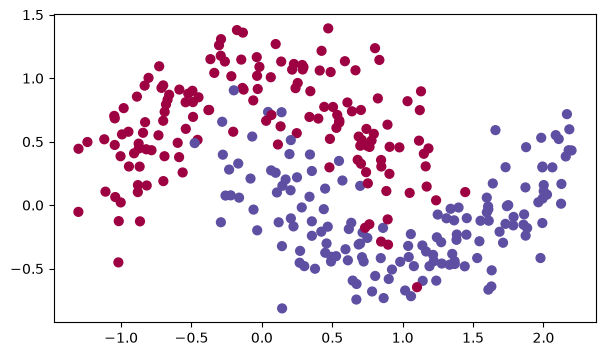

In [32]:
train_X, train_Y = load_dataset()

In [37]:
def model(X, Y, layers_dims, optimizer, learning_rate = 0.0007, mini_batch_size = 64, beta = 0.9,
          beta1 = 0.9, beta2 = 0.999,  epsilon = 1e-8, num_epochs = 10000, print_cost = True):
          

    L = len(layers_dims)             # number of layers in the neural networks
    costs = []                       # to keep track of the cost
    t = 0                            # initializing the counter required for Adam update
    seed = 10                        # For grading purposes, so that your "random" minibatches are the same as ours
    
    # Initialize parameters
    parameters = initialize_parameters(layers_dims)

    # Initialize the optimizer
    if optimizer == "gd":
        pass # no initialization required for gradient descent
    elif optimizer == "momentum":
        v = initialize_velocity(parameters)
    elif optimizer == "adam":
        v, s = initialize_adam(parameters)
    
    # Optimization loop
    for i in range(num_epochs):
                # Define the random minibatches. We increment the seed to reshuffle differently the dataset after each epoch
        seed = seed + 1
        minibatches = random_mini_batches(X, Y, mini_batch_size, seed)

        for minibatch in minibatches:

            # Select a minibatch
            (minibatch_X, minibatch_Y) = minibatch

            # Forward propagation
            a3, caches = forward_propagation(minibatch_X, parameters)

            # Compute cost
            cost = compute_cost(a3, minibatch_Y)

            # Backward propagation
            grads = backward_propagation(minibatch_X, minibatch_Y, caches)

            # Update parameters
            if optimizer == "gd":
                parameters = update_parameters_with_gd(parameters, grads, learning_rate)
            elif optimizer == "momentum":
                parameters, v = update_parameters_with_momentum(parameters, grads, v, beta, learning_rate)
            elif optimizer == "adam":
                t = t + 1 # Adam counter
                parameters, v, s = update_parameters_with_adam(parameters, grads, v, s,
                                                               t, learning_rate, beta1, beta2,  epsilon)
        
        # Print the cost every 1000 epoch
        if print_cost and i % 1000 == 0:
            print ("Cost after epoch %i: %f" %(i, cost))
        if print_cost and i % 100 == 0:
            costs.append(cost)
                
    # plot the cost
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('epochs (per 100)')
    plt.title("Learning rate = " + str(learning_rate))
    plt.show()

    return parameters

Cost after epoch 0: 0.690736
Cost after epoch 1000: 0.685273
Cost after epoch 2000: 0.647072
Cost after epoch 3000: 0.619525
Cost after epoch 4000: 0.576584
Cost after epoch 5000: 0.607243
Cost after epoch 6000: 0.529403
Cost after epoch 7000: 0.460768
Cost after epoch 8000: 0.465586
Cost after epoch 9000: 0.464518


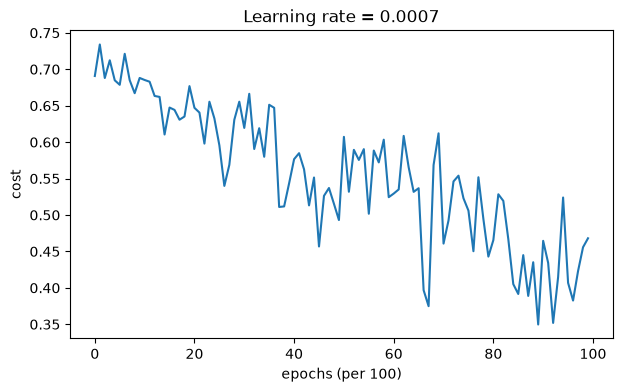

Accuracy: 0.7966666666666666


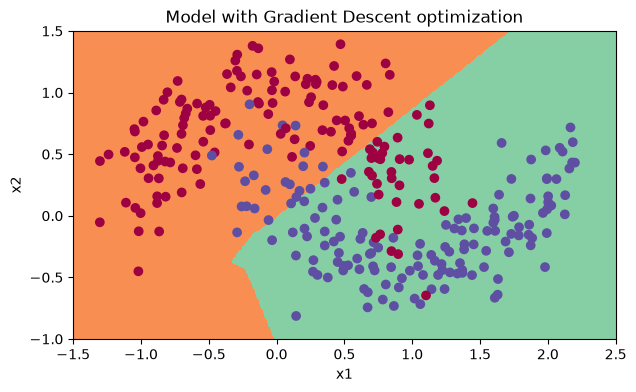

In [34]:
# train 3-layer model
layers_dims = [train_X.shape[0], 5, 2, 1]
parameters = model(train_X, train_Y, layers_dims, optimizer = "gd")

# Predict
predictions = predict(train_X, train_Y, parameters)

# Plot decision boundary
plt.title("Model with Gradient Descent optimization")
axes = plt.gca()
axes.set_xlim([-1.5,2.5])
axes.set_ylim([-1,1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

Cost after epoch 0: 0.690552
Cost after epoch 1000: 0.185567
Cost after epoch 2000: 0.150852
Cost after epoch 3000: 0.074454
Cost after epoch 4000: 0.125936
Cost after epoch 5000: 0.104235
Cost after epoch 6000: 0.100552
Cost after epoch 7000: 0.031601
Cost after epoch 8000: 0.111709
Cost after epoch 9000: 0.197648


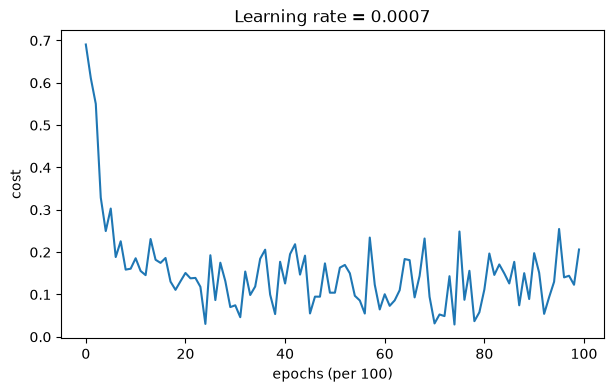

Accuracy: 0.94


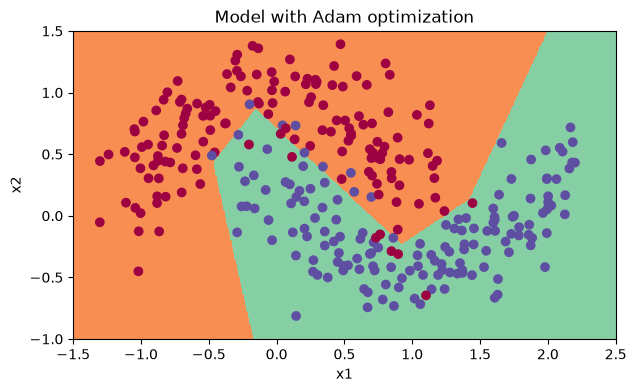

In [36]:

layers_dims = [train_X.shape[0], 5, 2, 1]
parameters = model(train_X, train_Y, layers_dims, optimizer = "adam")


predictions = predict(train_X, train_Y, parameters)


plt.title("Model with Adam optimization")
axes = plt.gca()
axes.set_xlim([-1.5,2.5])
axes.set_ylim([-1,1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)